In [1]:
import numpy as np
from numba import njit , prange
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from scipy.stats import skew
from scipy.ndimage import uniform_filter1d
from scipy.signal import hilbert
import pandas as pd
from tqdm import tqdm
import progressbar 
import os, json, time, gc, io, contextlib, math
from numba import set_num_threads, get_num_threads
from operator import mod
from itertools import product
from statsmodels.tsa.stattools import adfuller
from itertools import permutations
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
import glob
import imageio.v2 as imageio
from scipy.integrate import solve_ivp
from math import comb
from scipy.interpolate import interp1d
from pathlib import Path
from loguru import logger
import typer
import sys
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy.stats import gaussian_kde
from scipy.stats import rayleigh, gamma, lognorm
from scipy.stats import ecdf

PROJ_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJ_ROOT))
REPORTS_DIR = PROJ_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
DATA_DIR = PROJ_ROOT / "data" / "raw"

import moran.methods as methods
import moran.config as config
import moran.plots as plots

g=1

2026-06-17 17:00:51.100 | INFO     | moran.config:<module>:11 - PROJ_ROOT path is: C:\Users\ah741\Desktop\fitness_waves


In [ ]:
%matplotlib widget


from matplotlib.widgets import Slider


In [2]:
n_individuals = 20000
b1_rate = 0.1
d1_rate = 0.1
bpd=b1_rate+d1_rate; g=1 ;dt = 0.01 ;PR0=0.01
skip = 5
tmax = 10005
t_lag = 200
n_ensemble = 128 
indices = np.arange(skip*n_individuals, tmax*n_individuals, t_lag) 

ex_name = f"4D_N({n_individuals})_b1({b1_rate})d1({d1_rate})_tmax({tmax})_n_ensemble({n_ensemble})"


M = np.load(os.path.join(DATA_DIR, ex_name, "M.npy")  )
Mdot = np.load(os.path.join(DATA_DIR, ex_name, "Mdot.npy")  )
Vdot = np.load(os.path.join(DATA_DIR, ex_name, "Vdot.npy")  )
Tdot = np.load(os.path.join(DATA_DIR, ex_name, "Sdot.npy")  )


In [3]:
save_dir = PROJ_ROOT / "data" / "processed" / "ATXB"
data = np.load(save_dir / "ATXB_data.npz")
x = data['x']
AVG_HIST = data['AVG_HIST']
branching = data['branching']

In [4]:
df = pd.read_parquet(PROJ_ROOT / "data" / "processed" / "ensemble_results_1.3_1.parquet")

In [5]:
# df = pd.DataFrame(results)

df_clean = df[df["valid"]].dropna(subset=["waiting_time", "dmu0"])

# Bivariate PDF
waiting_times = df_clean["waiting_time"].values
dmu0s         = df_clean["dmu0"].values

kde = gaussian_kde(np.vstack([waiting_times, dmu0s]))

# Evaluate on a grid
wt_grid  = np.linspace(waiting_times.min(), waiting_times.max(), 100)
dmu_grid = np.linspace(dmu0s.min(),         dmu0s.max(),         100)
WW, DD   = np.meshgrid(wt_grid, dmu_grid)
Z        = kde(np.vstack([WW.ravel(), DD.ravel()])).reshape(WW.shape)

In [12]:
dmu0s

array([9.12063886, 6.33805858, 7.36015992, ..., 6.11780257, 9.32624577,
       6.85998101], shape=(3430,))

73 0.013231749999999988


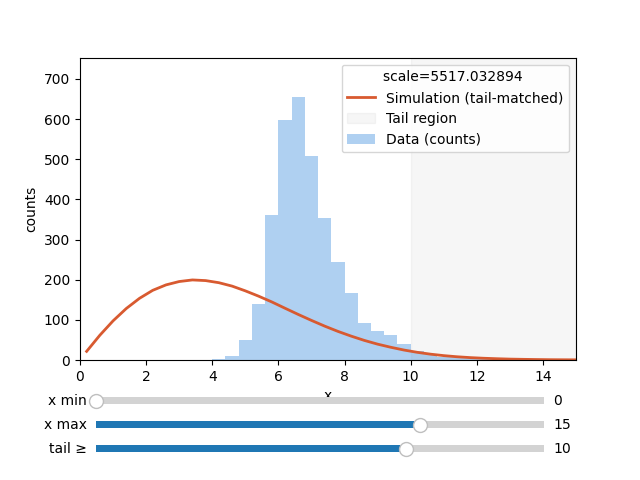

In [ ]:
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# --- Your real data goes here ---
# dataCounts : array of raw bin counts from np.histogram
# simRaw     : AVG_HIST * branching (not normalized)
# bin_centers: centers of the histogram bins

hist_bins   = np.linspace(0, 20, 51)
bin_centers = 0.5 * (hist_bins[:-1] + hist_bins[1:])
bin_width   = hist_bins[1] - hist_bins[0]

x_data      = df_clean["dmu0"].values
dataCounts, _ = np.histogram(x_data, bins=hist_bins)

nonzero  = np.nonzero(AVG_HIST)[0]
lo, hi   = nonzero[0], nonzero[-1] + 1
simRaw   = np.interp(bin_centers, x[lo:hi], AVG_HIST[lo:hi] * branching[lo:hi],
                     left=0, right=0)

simRaw = np.interp(
    bin_centers,
    x[lo:hi],
    AVG_HIST[lo:hi]
    * branching[lo:hi]
    * (1 + b*x[lo:hi])**alpha_fit,
    left=0,
    right=0
)

# --- Initial params ---
XMIN_INIT  = 0.0
XMAX_INIT  = 15.0
TAIL_INIT  = 10.0

def get_scale(xmax, tail_lo):
    tail_mask = (bin_centers >= tail_lo) & (bin_centers <= xmax)
    denom = np.sum(simRaw[tail_mask])
    print(np.sum(dataCounts[tail_mask]), denom )
    return np.sum(dataCounts[tail_mask]) / denom if denom > 0 else 1.0

def draw(xmin, xmax, tail_lo):
    ax.cla()
    scale      = get_scale(xmax, tail_lo)
    sim_scaled = simRaw * scale

    mask = (bin_centers >= xmin) & (bin_centers <= xmax)
    bc   = bin_centers[mask]
    dc   = dataCounts[mask]
    sc   = sim_scaled[mask]

    ax.bar(bc, dc, width=bin_width, alpha=0.4, color="#378ADD",
           label="Data (counts)")
    ax.plot(bc, sc, color="#D85A30", linewidth=2,
            label="Simulation (tail-matched)")

    # shade tail region
    tail_mask = (bc >= tail_lo)
    ax.axvspan(tail_lo, xmax, alpha=0.07, color="gray", label="Tail region")

    ymax = max(dc.max(), sc.max()) * 1.15 if len(dc) > 0 else 1
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("counts")
    ax.legend(loc="upper right", title=f"scale={scale:.6f} ") #  eff={1/scale:.3f}
    fig.canvas.draw_idle()

# --- Sliders ---
ax_xmin = plt.axes([0.15, 0.15, 0.70, 0.03])
ax_xmax = plt.axes([0.15, 0.10, 0.70, 0.03])
ax_tail = plt.axes([0.15, 0.05, 0.70, 0.03])

s_xmin = Slider(ax_xmin, "x min",  0.0, 13.0, valinit=XMIN_INIT, valstep=0.5)
s_xmax = Slider(ax_xmax, "x max",  2.0, 20.0, valinit=XMAX_INIT, valstep=0.5)
s_tail = Slider(ax_tail, "tail ≥", 1.0, 14.0, valinit=TAIL_INIT,  valstep=0.5)

def on_change(_):
    draw(s_xmin.val, s_xmax.val, s_tail.val)

s_xmin.on_changed(on_change)
s_xmax.on_changed(on_change)
s_tail.on_changed(on_change)

draw(XMIN_INIT, XMAX_INIT, TAIL_INIT)
plt.show()

In [21]:
P_pop_branch = np.interp(bin_centers, x, AVG_HIST * branching, left=0, right=0)
P_pop_branch /= np.sum(P_pop_branch)
P_events = dataCounts / np.sum(dataCounts)
ratio = np.divide(P_events, P_pop_branch, out=np.full_like(P_events, np.nan, dtype=float), where=P_pop_branch > 0)

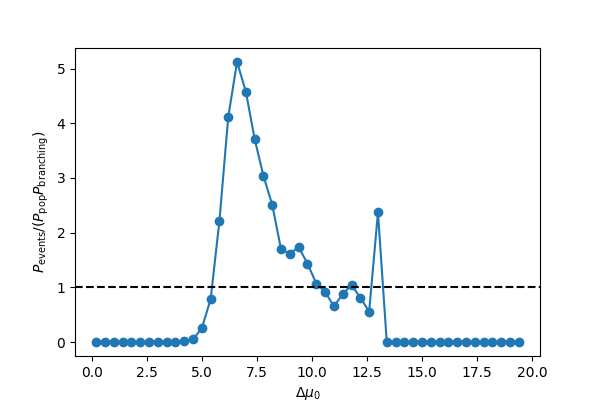

In [22]:
plt.figure(figsize=(6,4))
plt.plot(bin_centers, ratio, 'o-')
plt.axhline(1, color='k', ls='--')
plt.xlabel(r'$\Delta \mu_0$')
plt.ylabel(r'$P_{\rm events}/(P_{\rm pop}P_{\rm branching})$')
plt.show()

In [30]:
lo,hi

(np.int64(0), np.int64(4762))

In [ ]:
from scipy.optimize import minimize_scalar

# observed counts
obs = dataCounts.copy()

# birth function
b=0.1
birth = 1 + b * x

def build_prediction(alpha):
    return AVG_HIST * branching * birth**alpha

def fit_alpha():

    def objective(alpha):

        pred_raw = build_prediction(alpha)

        # interpolate onto histogram bins
        pred = np.interp(bin_centers, x, pred_raw, left=0, right=0)

        # match total counts
        scale = obs.sum() / pred.sum()

        pred *= scale

        return np.sum((obs - pred)**2)

    res = minimize_scalar(
        objective,
        bounds=(0, 50),
        method="bounded"
    )

    return res.x

alpha_fit = fit_alpha()

print("alpha =", alpha_fit)

alpha = 5.909388785239434


C:\Users\ah741\AppData\Local\Temp\ipykernel_28228\1283852050.py:11: RuntimeWarning: invalid value encountered in power
  return AVG_HIST[lo:hi] * branching[lo:hi] * birth**alpha


3430 2.4894316639789995


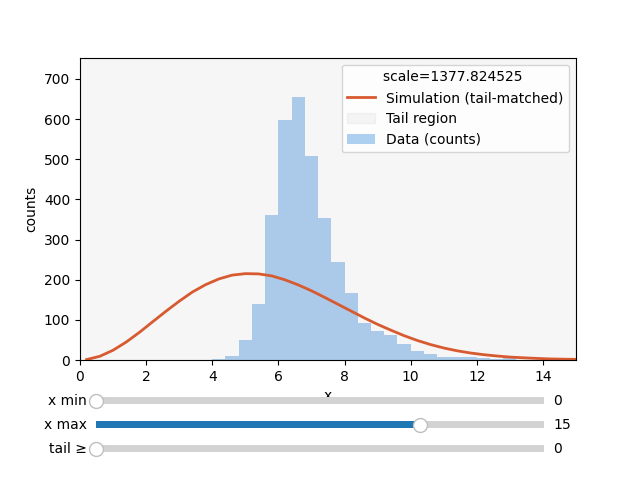

In [ ]:
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# --- Your real data goes here ---
# dataCounts : array of raw bin counts from np.histogram
# simRaw     : AVG_HIST * branching (not normalized)
# bin_centers: centers of the histogram bins

hist_bins   = np.linspace(0, 20, 51)
bin_centers = 0.5 * (hist_bins[:-1] + hist_bins[1:])
bin_width   = hist_bins[1] - hist_bins[0]

x_data      = df_clean["dmu0"].values
dataCounts, _ = np.histogram(x_data, bins=hist_bins)

nonzero  = np.nonzero(AVG_HIST)[0]
lo, hi   = nonzero[0], nonzero[-1] + 1
# simRaw   = np.interp(bin_centers, x[lo:hi], AVG_HIST[lo:hi] * branching[lo:hi], left=0, right=0)

simRaw = np.interp(bin_centers, x[lo:hi], AVG_HIST[lo:hi] * branching[lo:hi] * (1 + b*x[lo:hi])**1, left=0, right=0)

# --- Initial params ---
XMIN_INIT  = 0.0
XMAX_INIT  = 15.0
TAIL_INIT  = 0

def get_scale(xmax, tail_lo):
    tail_mask = (bin_centers >= tail_lo) & (bin_centers <= xmax)
    denom = np.sum(simRaw[tail_mask])
    print(np.sum(dataCounts[tail_mask]), denom )
    return np.sum(dataCounts[tail_mask]) / denom if denom > 0 else 1.0

def draw(xmin, xmax, tail_lo):
    ax.cla()
    scale      = get_scale(xmax, tail_lo)
    sim_scaled = simRaw * scale

    mask = (bin_centers >= xmin) & (bin_centers <= xmax)
    bc   = bin_centers[mask]
    dc   = dataCounts[mask]
    sc   = sim_scaled[mask]

    ax.bar(bc, dc, width=bin_width, alpha=0.4, color="#378ADD",
           label="Data (counts)")
    ax.plot(bc, sc, color="#D85A30", linewidth=2,
            label="Simulation (tail-matched)")

    # shade tail region
    tail_mask = (bc >= tail_lo)
    ax.axvspan(tail_lo, xmax, alpha=0.07, color="gray", label="Tail region")

    ymax = max(dc.max(), sc.max()) * 1.15 if len(dc) > 0 else 1
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("counts")
    ax.legend(loc="upper right", title=f"scale={scale:.6f} ") #  eff={1/scale:.3f}
    fig.canvas.draw_idle()

# --- Sliders ---
ax_xmin = plt.axes([0.15, 0.15, 0.70, 0.03])
ax_xmax = plt.axes([0.15, 0.10, 0.70, 0.03])
ax_tail = plt.axes([0.15, 0.05, 0.70, 0.03])

s_xmin = Slider(ax_xmin, "x min",  0.0, 13.0, valinit=XMIN_INIT, valstep=0.5)
s_xmax = Slider(ax_xmax, "x max",  2.0, 20.0, valinit=XMAX_INIT, valstep=0.5)
s_tail = Slider(ax_tail, "tail ≥", 0, 14.0, valinit=TAIL_INIT,  valstep=0.5)

def on_change(_):
    draw(s_xmin.val, s_xmax.val, s_tail.val)

s_xmin.on_changed(on_change)
s_xmax.on_changed(on_change)
s_tail.on_changed(on_change)

draw(XMIN_INIT, XMAX_INIT, TAIL_INIT)
plt.show()

In [12]:
tune_params = {  "M_sigma": 30, "M_height_mean": 0.5, "M_height_std": 0,   "M_distance": 100,
                 "V_sigma": 30, "V_height_mean": 0, "V_height_std": 0,   "V_distance": 100,
                 "T_sigma": 30, "T_height_mean": 0, "T_height_std": 0.4, "T_distance": 100,
                  "time_tol": 0.6    }
results = methods.detect_events_ensemble_fast(Mdot, Vdot, Tdot, skip, tmax, t_lag, n_individuals, tune_params)
event_times_all = results[0]
dt_Vpk_Vtr_all = results[1]

In [32]:
raw_waiting_times = []
for i in range(20):
    event_times = event_times_all[i] - skip
    wt = np.diff(event_times)
    wt = np.concatenate([[np.nan], wt])  # first event has no previous
    raw_waiting_times.append(wt)

# sum of all events
all_events = np.concatenate(event_times_all)
all_events = all_events[~np.isnan(all_events)]
len(all_events)

167360

In [ ]:
def process_ensemble(i, event_times_i, dt_Vpk_Vtr_i, Vdot_i, Mdot_i, Tdot_i,
                     PR0, bpd, g, dt, skip):

    event_times = event_times_i - skip

    # first pass
    raw = []
    for j in range(len(event_times)):
        event_time  = int(event_times[j] * 100)
        deltatevent = int(dt_Vpk_Vtr_i[j] * 100)
        ddtt        = int(deltatevent / 1.5)
        plotstart   = event_time - ddtt
        plotend     = event_time + ddtt

        V_data = Vdot_i[plotstart:plotend]
        M_data = Mdot_i[plotstart:plotend]
        T_data = Tdot_i[plotstart:plotend]

        T_min = np.min(T_data)
        deltamu0initial = (-T_min*8/bpd)**(1/4)
        bounds = [(0.5, 40)]

        dmu0, total_loss = methods.opt_dv0_3(V_data, M_data, T_data, deltamu0initial, bounds,
                                     PR0, bpd, g, dt, loss_type="L1")

        raw.append({
            "j":          j,
            "event_time": event_times[j],
            "delta_t":    dt_Vpk_Vtr_i[j],
            "plotstart":  plotstart,
            "plotend":    plotend,
            "dmu0":       dmu0,
            "total_loss": total_loss,
            "valid":      total_loss < 1e9,
        })

    # second pass: waiting times + collect nan windows
    valid_so_far = []
    ensemble_results = []
    nan_windows = []  # (plotstart, plotend) for valid events

    for r in raw:
        if r["valid"]:
            waiting_time = np.nan if len(valid_so_far) == 0 else (
                (r["event_time"] - valid_so_far[-1]["event_time"])
                - (valid_so_far[-1]["delta_t"] + r["delta_t"]) / 2
            )
            nan_windows.append((r["plotstart"], r["plotend"]))
            valid_so_far.append(r)
        else:
            waiting_time = np.nan

        ensemble_results.append({
            "ensemble":     i,
            "event_idx":    r["j"],
            "event_time":   r["event_time"],
            "delta_t":      r["delta_t"],
            "waiting_time": waiting_time,
            "dmu0":         r["dmu0"],
            "total_loss":   r["total_loss"],
            "valid":        r["valid"],
        })

    return ensemble_results, nan_windows


Mdot_no_events = [np.array(m, dtype=float) for m in Mdot]

outputs = Parallel(n_jobs=-1)( delayed(process_ensemble)(i, event_times_all[i], dt_Vpk_Vtr_all[i], Vdot[i], Mdot[i], Tdot[i], PR0, bpd, g, dt, skip ) for i in range(10) )

results = []
for i, (ensemble_results, nan_windows) in enumerate(outputs):
    results.extend(ensemble_results)
    for plotstart, plotend in nan_windows:
        Mdot_no_events[i][plotstart:plotend] = np.nan

In [14]:
df = pd.DataFrame(results)
df.to_parquet(PROJ_ROOT / "data" / "processed" / "ensemble_results_0.5_0.4.parquet") 

In [21]:
df = pd.read_parquet(PROJ_ROOT / "data" / "processed" / "ensemble_results_0.5_0.4.parquet")

In [22]:
df = pd.DataFrame(results)

df_clean = df[df["valid"]].dropna(subset=["waiting_time", "dmu0"])

# Bivariate PDF
waiting_times = df_clean["waiting_time"].values
dmu0s         = df_clean["dmu0"].values

kde = gaussian_kde(np.vstack([waiting_times, dmu0s]))

# Evaluate on a grid
wt_grid  = np.linspace(waiting_times.min(), waiting_times.max(), 100)
dmu_grid = np.linspace(dmu0s.min(),         dmu0s.max(),         100)
WW, DD   = np.meshgrid(wt_grid, dmu_grid)
Z        = kde(np.vstack([WW.ravel(), DD.ravel()])).reshape(WW.shape)

In [23]:
dmu0s

array([5.68574074, 5.35452504, 4.47655763, ..., 3.83517982, 3.97941752,
       4.90833869], shape=(12930,))

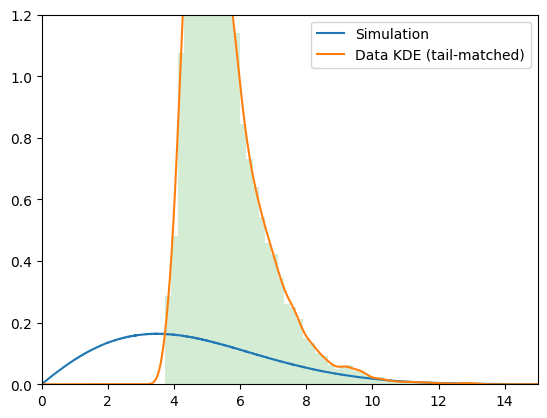

Scale factor applied to data: 4.2258
Implied detection efficiency: 0.2366


In [35]:
fig, ax = plt.subplots()

# --- Simulation avg PDF (same as before) ---
nonzero = np.nonzero(AVG_HIST)[0]
lo, hi  = nonzero[0], nonzero[-1] + 1
x_sim   = x
y_sim   = AVG_HIST[lo:hi] * branching

mask_full = (x_sim >= 0) & (x_sim <= 15)
norm      = np.sum(y_sim[mask_full]) * 0.01
y_sim     = y_sim / norm

# --- Data KDE ---
x_data = df_clean["dmu0"].values
kde_1D = gaussian_kde(x_data)
grid   = np.linspace(0, 15, 1500)
y_kde  = kde_1D(grid)
dx     = grid[1] - grid[0]

# --- Tail-match rescaling ---
# Pick the tail region where detection is complete
TAIL_LO, TAIL_HI = 10, 14

# Integral of simulation in tail
tail_mask_sim = (x_sim >= TAIL_LO) & (x_sim <= TAIL_HI)
sim_tail_norm = np.sum(y_sim[tail_mask_sim]) * 0.01

# Integral of KDE in tail
tail_mask_kde = (grid >= TAIL_LO) & (grid <= TAIL_HI)
kde_tail_norm = np.sum(y_kde[tail_mask_kde]) * dx

# Scale factor: how much to multiply the KDE so its tail matches sim
scale = sim_tail_norm / kde_tail_norm
y_kde_scaled = y_kde * scale

# Same scale applies to the histogram
ax.plot(x_sim, y_sim, label="Simulation")
ax.plot(grid, y_kde_scaled, label="Data KDE (tail-matched)")
# ax.hist(x_data, bins=50, density=True, alpha=0.2, weights=np.full(len(x_data), scale))
ax.hist(x_data, bins=50, alpha=0.2, weights=np.full(len(x_data), scale / (len(x_data) * (x_data.max() - x_data.min()) / 50)))

ax.set_xlim((0, 15))
ax.set_ylim((0, 1.2))
ax.legend()
plt.show()


print(f"Scale factor applied to data: {scale:.4f}")
print(f"Implied detection efficiency: {1/scale:.4f}")

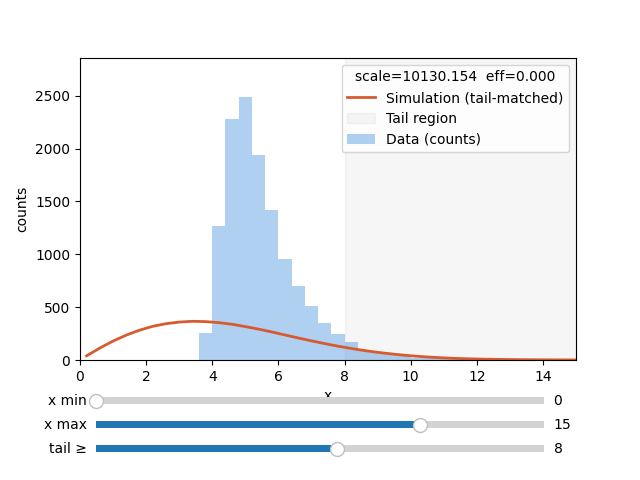

In [17]:
%matplotlib widget


from matplotlib.widgets import Slider

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# --- Your real data goes here ---
# dataCounts : array of raw bin counts from np.histogram
# simRaw     : AVG_HIST * branching (not normalized)
# bin_centers: centers of the histogram bins

hist_bins   = np.linspace(0, 20, 51)
bin_centers = 0.5 * (hist_bins[:-1] + hist_bins[1:])
bin_width   = hist_bins[1] - hist_bins[0]

x_data      = df_clean["dmu0"].values
dataCounts, _ = np.histogram(x_data, bins=hist_bins)

nonzero  = np.nonzero(AVG_HIST)[0]
lo, hi   = nonzero[0], nonzero[-1] + 1
simRaw   = np.interp(bin_centers, x[lo:hi], AVG_HIST[lo:hi] * branching[lo:hi],
                     left=0, right=0)

# --- Initial params ---
XMIN_INIT  = 0.0
XMAX_INIT  = 15.0
TAIL_INIT  = 8.0

def get_scale(xmax, tail_lo):
    tail_mask = (bin_centers >= tail_lo) & (bin_centers <= xmax)
    denom = np.sum(simRaw[tail_mask])
    return np.sum(dataCounts[tail_mask]) / denom if denom > 0 else 1.0

def draw(xmin, xmax, tail_lo):
    ax.cla()
    scale      = get_scale(xmax, tail_lo)
    sim_scaled = simRaw * scale

    mask = (bin_centers >= xmin) & (bin_centers <= xmax)
    bc   = bin_centers[mask]
    dc   = dataCounts[mask]
    sc   = sim_scaled[mask]

    ax.bar(bc, dc, width=bin_width, alpha=0.4, color="#378ADD",
           label="Data (counts)")
    ax.plot(bc, sc, color="#D85A30", linewidth=2,
            label="Simulation (tail-matched)")

    # shade tail region
    tail_mask = (bc >= tail_lo)
    ax.axvspan(tail_lo, xmax, alpha=0.07, color="gray", label="Tail region")

    ymax = max(dc.max(), sc.max()) * 1.15 if len(dc) > 0 else 1
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("counts")
    ax.legend(loc="upper right",
              title=f"scale={scale:.3f}  eff={1/scale:.3f}")
    fig.canvas.draw_idle()

# --- Sliders ---
ax_xmin = plt.axes([0.15, 0.15, 0.70, 0.03])
ax_xmax = plt.axes([0.15, 0.10, 0.70, 0.03])
ax_tail = plt.axes([0.15, 0.05, 0.70, 0.03])

s_xmin = Slider(ax_xmin, "x min",  0.0, 13.0, valinit=XMIN_INIT, valstep=0.5)
s_xmax = Slider(ax_xmax, "x max",  2.0, 20.0, valinit=XMAX_INIT, valstep=0.5)
s_tail = Slider(ax_tail, "tail ≥", 1.0, 14.0, valinit=TAIL_INIT,  valstep=0.5)

def on_change(_):
    draw(s_xmin.val, s_xmax.val, s_tail.val)

s_xmin.on_changed(on_change)
s_xmax.on_changed(on_change)
s_tail.on_changed(on_change)

draw(XMIN_INIT, XMAX_INIT, TAIL_INIT)
plt.show()

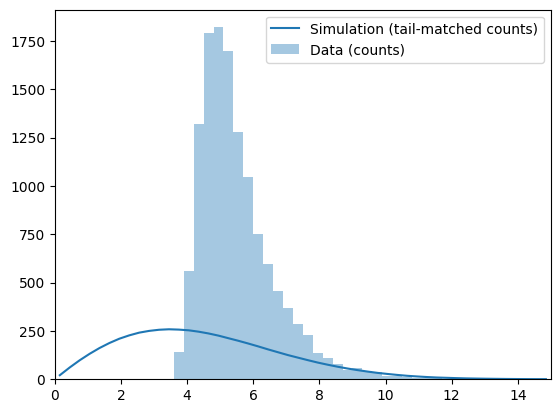

Tail scale factor: 7148.7935
Implied total detected fraction: 2.4583


In [36]:
fig, ax = plt.subplots()

# --- Data histogram (raw counts) ---
hist_bins = np.linspace(0, 15, 51)
bin_width  = hist_bins[1] - hist_bins[0]
counts, _  = np.histogram(x_data, bins=hist_bins)

# --- Simulation: convert AVG_HIST (PDF) to predicted counts per bin ---
# AVG_HIST * branching gives shape; scale to counts via tail matching
nonzero = np.nonzero(AVG_HIST)[0]
lo, hi  = nonzero[0], nonzero[-1] + 1
x_sim   = x                          # your bin centers/edges array
y_sim   = AVG_HIST[lo:hi] * branching  # raw shape, not yet normalized

# Interpolate simulation onto the same bin centers as the data histogram
bin_centers = 0.5 * (hist_bins[:-1] + hist_bins[1:])
y_sim_interp = np.interp(bin_centers, x_sim, y_sim, left=0, right=0)

# --- Tail-match: scale simulation counts to data counts in tail ---
TAIL_LO, TAIL_HI = 8, 15
tail_mask = (bin_centers >= TAIL_LO) & (bin_centers <= TAIL_HI)

scale = np.sum(counts[tail_mask]) / np.sum(y_sim_interp[tail_mask])
y_sim_counts = y_sim_interp * scale

# --- Plot ---
ax.bar(bin_centers, counts, width=bin_width, alpha=0.4, label="Data (counts)")
ax.plot(bin_centers, y_sim_counts, label="Simulation (tail-matched counts)")

ax.set_xlim((0, 15))
ax.legend()
plt.show()

print(f"Tail scale factor: {scale:.4f}")
print(f"Implied total detected fraction: {np.sum(counts) / np.sum(y_sim_counts):.4f}")

In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
matplotlib.use("TkAgg")  # or "TkAgg"  or "QtAgg"

plt.ion()
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# --- Your real data goes here ---
# dataCounts : array of raw bin counts from np.histogram
# simRaw     : AVG_HIST * branching (not normalized)
# bin_centers: centers of the histogram bins

hist_bins   = np.linspace(0, 20, 51)
bin_centers = 0.5 * (hist_bins[:-1] + hist_bins[1:])
bin_width   = hist_bins[1] - hist_bins[0]

x_data      = df_clean["dmu0"].values
dataCounts, _ = np.histogram(x_data, bins=hist_bins)

nonzero  = np.nonzero(AVG_HIST)[0]
lo, hi   = nonzero[0], nonzero[-1] + 1
simRaw   = np.interp(bin_centers, x[lo:hi], AVG_HIST[lo:hi] * branching[lo:hi],
                     left=0, right=0)

# --- Initial params ---
XMIN_INIT  = 0.0
XMAX_INIT  = 15.0
TAIL_INIT  = 8.0

def get_scale(xmax, tail_lo):
    tail_mask = (bin_centers >= tail_lo) & (bin_centers <= xmax)
    denom = np.sum(simRaw[tail_mask])
    return np.sum(dataCounts[tail_mask]) / denom if denom > 0 else 1.0

def draw(xmin, xmax, tail_lo):
    ax.cla()
    scale      = get_scale(xmax, tail_lo)
    sim_scaled = simRaw * scale

    mask = (bin_centers >= xmin) & (bin_centers <= xmax)
    bc   = bin_centers[mask]
    dc   = dataCounts[mask]
    sc   = sim_scaled[mask]

    ax.bar(bc, dc, width=bin_width, alpha=0.4, color="#378ADD",
           label="Data (counts)")
    ax.plot(bc, sc, color="#D85A30", linewidth=2,
            label="Simulation (tail-matched)")

    # shade tail region
    tail_mask = (bc >= tail_lo)
    ax.axvspan(tail_lo, xmax, alpha=0.07, color="gray", label="Tail region")

    ymax = max(dc.max(), sc.max()) * 1.15 if len(dc) > 0 else 1
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("counts")
    ax.legend(loc="upper right",
              title=f"scale={scale:.3f}  eff={1/scale:.3f}")
    fig.canvas.draw_idle()

# --- Sliders ---
ax_xmin = plt.axes([0.15, 0.15, 0.70, 0.03])
ax_xmax = plt.axes([0.15, 0.10, 0.70, 0.03])
ax_tail = plt.axes([0.15, 0.05, 0.70, 0.03])

s_xmin = Slider(ax_xmin, "x min",  0.0, 13.0, valinit=XMIN_INIT, valstep=0.5)
s_xmax = Slider(ax_xmax, "x max",  2.0, 20.0, valinit=XMAX_INIT, valstep=0.5)
s_tail = Slider(ax_tail, "tail ≥", 1.0, 14.0, valinit=TAIL_INIT,  valstep=0.5)

def on_change(_):
    draw(s_xmin.val, s_xmax.val, s_tail.val)

s_xmin.on_changed(on_change)
s_xmax.on_changed(on_change)
s_tail.on_changed(on_change)

draw(XMIN_INIT, XMAX_INIT, TAIL_INIT)
plt.show()

NameError: name 'df_clean' is not defined

In [39]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline
